# Customer Segmentation with K-Means

## Business Objective

This project explores customer purchasing behaviour to identify meaningful customer segments using unsupervised machine learning.

The analysis uses transactional retail data to group customers with similar purchasing patterns and translate the resulting clusters into actionable business insights.

In [1]:
!pip install -q ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Load the Online Retail dataset from the UCI Machine Learning Repository
online_retail = fetch_ucirepo(id=352)

# Create a working copy of the complete dataset
df = online_retail.data.original.copy()

# Display the first rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Dataset Overview

Before preparing the data for customer segmentation, we first examine its structure, dimensions and data quality.

In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### Initial Data Quality Findings

The dataset contains 541,909 transactions across 8 variables.

Missing values are concentrated in two fields:

- `Description`: 1,454 missing values.
- `CustomerID`: 135,080 missing values.

Because customer segmentation requires transactions to be linked to identifiable customers, records without a `CustomerID` cannot contribute to customer-level profiles and will be removed.

Missing product descriptions will not be used as an exclusion criterion at this stage, since the remaining transaction attributes may still provide useful information for the analysis.

In [4]:
print("Duplicate rows:", df.duplicated().sum())

print("\nQuantity <= 0:", (df["Quantity"] <= 0).sum())

print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

Duplicate rows: 5268

Quantity <= 0: 10624
UnitPrice <= 0: 2517


In [5]:
df[df["Quantity"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom


In [6]:
negative_qty = df[df["Quantity"] < 0].copy()

print("Negative quantity rows:", len(negative_qty))
print(
    "Invoices starting with C:",
    negative_qty["InvoiceNo"].astype(str).str.startswith("C").sum()
)

negative_qty[
    ["InvoiceNo", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(10)

Negative quantity rows: 10624
Invoices starting with C: 9288


,InvoiceNo,Description,Quantity,UnitPrice,CustomerID
141,C536379,Discount,-1,27.50,14527.0
154,C536383,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0
235,C536391,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0
236,C536391,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0
237,C536391,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0
238,C536391,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,17548.0
239,C536391,CHICK GREY HOT WATER BOTTLE,-12,3.45,17548.0
240,C536391,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,17548.0
241,C536391,PLASTERS IN TIN SKULLS,-24,1.65,17548.0
939,C536506,JAM MAKING SET WITH JARS,-6,4.25,17897.0


In [7]:
negative_non_c = negative_qty[
    ~negative_qty["InvoiceNo"].astype(str).str.startswith("C")
]

print("Negative quantity rows without C prefix:", len(negative_non_c))

negative_non_c[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

Negative quantity rows without C prefix: 1336


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
2406,536589,21777,NaN,-10,0.0,NaN
4347,536764,84952C,NaN,-38,0.0,NaN
7188,536996,22712,NaN,-20,0.0,NaN
7189,536997,22028,NaN,-20,0.0,NaN
7190,536998,85067,NaN,-6,0.0,NaN
7192,537000,21414,NaN,-22,0.0,NaN
7193,537001,21653,NaN,-6,0.0,NaN
7195,537003,85126,NaN,-2,0.0,NaN
7196,537004,21814,NaN,-30,0.0,NaN
7197,537005,21692,NaN,-70,0.0,NaN


In [8]:
print(
    "Missing CustomerID:",
    negative_non_c["CustomerID"].isna().sum()
)

print(
    "Missing Description:",
    negative_non_c["Description"].isna().sum()
)

print(
    "Rows with a valid CustomerID:",
    negative_non_c["CustomerID"].notna().sum()
)

Missing CustomerID: 1336
Missing Description: 862
Rows with a valid CustomerID: 0


In [9]:
zero_or_negative_price = df[df["UnitPrice"] <= 0].copy()

print("Rows with UnitPrice <= 0:", len(zero_or_negative_price))
print(
    "Rows with a valid CustomerID:",
    zero_or_negative_price["CustomerID"].notna().sum()
)
print(
    "Rows with missing CustomerID:",
    zero_or_negative_price["CustomerID"].isna().sum()
)

zero_or_negative_price[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

Rows with UnitPrice <= 0: 2517
Rows with a valid CustomerID: 40
Rows with missing CustomerID: 2477


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
622,536414,22139,NaN,56,0.0,NaN
1970,536545,21134,NaN,1,0.0,NaN
1971,536546,22145,NaN,1,0.0,NaN
1972,536547,37509,NaN,1,0.0,NaN
1987,536549,85226A,NaN,1,0.0,NaN
1988,536550,85044,NaN,1,0.0,NaN
2024,536552,20950,NaN,1,0.0,NaN
2025,536553,37461,NaN,3,0.0,NaN
2026,536554,84670,NaN,23,0.0,NaN
2406,536589,21777,NaN,-10,0.0,NaN


In [10]:
valid_customer_zero_price = zero_or_negative_price[
    zero_or_negative_price["CustomerID"].notna()
].copy()

print(
    "UnitPrice = 0:",
    (valid_customer_zero_price["UnitPrice"] == 0).sum()
)

print(
    "UnitPrice < 0:",
    (valid_customer_zero_price["UnitPrice"] < 0).sum()
)

valid_customer_zero_price[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(40)

UnitPrice = 0: 40
UnitPrice < 0: 0


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,0.0,12647.0
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,0.0,16560.0
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,0.0,14911.0
47068,540372,22090,PAPER BUNTING RETROSPOT,24,0.0,13081.0
47070,540372,22553,PLASTERS IN TIN SKULLS,24,0.0,13081.0
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,0.0,15107.0
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,0.0,17560.0
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,0.0,13239.0
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,0.0,13113.0
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,0.0,14410.0


### Data Cleaning Strategy

Customer-level segmentation requires reliable purchase transactions. The following cleaning rules are therefore applied:

- Remove records without a `CustomerID`, since they cannot be assigned to a customer profile.
- Remove exact duplicate records.
- Exclude cancelled or returned transactions from the purchase-based segmentation.
- Retain only transactions with a positive `Quantity`.
- Retain only transactions with a positive `UnitPrice`.

The original dataset is preserved unchanged, and all transformations are applied to a separate working copy.

In [11]:
# Create a clean working copy
df_clean = df.copy()

# Keep only transactions linked to an identifiable customer
df_clean = df_clean[df_clean["CustomerID"].notna()]

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Exclude cancelled invoices
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only positive quantities and prices
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print("Remaining customers:", df_clean["CustomerID"].nunique())

Original rows: 541909
Clean rows: 392692
Rows removed: 149217
Remaining customers: 4338


In [12]:
# Calculate the monetary value of each transaction line
df_clean["TotalPrice"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

print("First transaction date:", df_clean["InvoiceDate"].min())
print("Last transaction date:", df_clean["InvoiceDate"].max())

df_clean[
    ["InvoiceNo", "CustomerID", "InvoiceDate", "Quantity", "UnitPrice", "TotalPrice"]
].head()

First transaction date: 1/10/2011 10:32
Last transaction date: 9/9/2011 9:52


,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,TotalPrice
0,536365,17850.0,12/1/2010 8:26,6,2.55,15.30
1,536365,17850.0,12/1/2010 8:26,6,3.39,20.34
2,536365,17850.0,12/1/2010 8:26,8,2.75,22.00
3,536365,17850.0,12/1/2010 8:26,6,3.39,20.34
4,536365,17850.0,12/1/2010 8:26,6,3.39,20.34


In [13]:
# Convert InvoiceDate from text to a proper datetime format
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"],
    format="%m/%d/%Y %H:%M"
)

print("First transaction date:", df_clean["InvoiceDate"].min())
print("Last transaction date:", df_clean["InvoiceDate"].max())

First transaction date: 2010-12-01 08:26:00
Last transaction date: 2011-12-09 12:50:00


In [14]:
# Define the reference date as one day after the last transaction
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Build customer-level RFM features
rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum")
    )
    .reset_index()
)

print("Customer profiles:", len(rfm))

rfm.head()

Customer profiles: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [15]:
rfm[["Recency", "Frequency", "Monetary"]].describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


In [16]:
rfm[["Recency", "Frequency", "Monetary"]].quantile(
    [0.90, 0.95, 0.99]
).round(2)

,Recency,Frequency,Monetary
0.90,263.0,9.0,3640.84
0.95,312.0,13.0,5790.00
0.99,369.0,30.0,19780.49


In [17]:
rfm[["Recency", "Frequency", "Monetary"]].skew().round(2)

,0
Recency,1.25
Frequency,12.07
Monetary,19.34


In [18]:
import numpy as np

# Apply a logarithmic transformation to reduce skewness
rfm_log = rfm.copy()

for column in ["Recency", "Frequency", "Monetary"]:
    rfm_log[column] = np.log1p(rfm_log[column])

# Check skewness after transformation
rfm_log[["Recency", "Frequency", "Monetary"]].skew().round(2)

,0
Recency,-0.38
Frequency,1.21
Monetary,0.40


In [19]:
from sklearn.preprocessing import StandardScaler

# Standardise the transformed RFM features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

print("Scaled data shape:", rfm_scaled.shape)
print("Feature means:", rfm_scaled.mean(axis=0).round(2))
print("Feature standard deviations:", rfm_scaled.std(axis=0).round(2))

Scaled data shape: (4338, 3)
Feature means: [-0. -0. -0.]
Feature standard deviations: [1. 1. 1.]


## Selecting the Number of Clusters

Rather than choosing the number of customer segments arbitrarily, several values of `k` are evaluated using both the Elbow Method and the Silhouette Score.

Combining these two approaches helps identify a clustering solution that balances compactness, separation and business interpretability.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

results.round(3)

,k,Inertia,Silhouette Score
0,2,6483.589,0.433
1,3,4869.489,0.337
2,4,3939.049,0.338
3,5,3296.709,0.316
4,6,2855.764,0.312
5,7,2548.820,0.309
6,8,2336.341,0.303
7,9,2156.006,0.281
8,10,2005.746,0.277


In [21]:
# Compare k=2 and k=4 using customer-level profiles

for k in [2, 4]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    comparison = rfm.copy()
    comparison["Cluster"] = labels

    print(f"\n--- k = {k} ---")

    print("\nCluster sizes:")
    print(
        comparison["Cluster"]
        .value_counts()
        .sort_index()
    )

    print("\nMedian RFM profile:")
    print(
        comparison
        .groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
        .median()
        .round(2)
    )


--- k = 2 ---

Cluster sizes:
Cluster
0    2672
1    1666
Name: count, dtype: int64

Median RFM profile:
         Recency  Frequency  Monetary
Cluster                              
0           96.0        1.0    363.08
1           16.0        6.0   2061.08

--- k = 4 ---

Cluster sizes:
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

Median RFM profile:
         Recency  Frequency  Monetary
Cluster                              
0            8.0       10.0   3722.82
1          174.5        1.0    296.09
2           17.0        2.0    480.31
3           57.0        4.0   1345.20


### Final Cluster Selection

The two-cluster solution achieved the highest Silhouette Score, indicating the strongest mathematical separation between groups. However, it produced only a broad distinction between lower-value and higher-value customers.

A four-cluster solution was selected because it provides substantially greater business interpretability while maintaining a reasonable level of cluster separation.

The four segments reveal distinct customer behaviours in terms of recency, purchase frequency and monetary value, allowing the analysis to distinguish highly engaged customers, regular customers, recent low-frequency customers and inactive low-value customers.

In [22]:
# Train the final K-Means model
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = final_kmeans.fit_predict(rfm_scaled)

# Assign business-friendly segment names
segment_names = {
    0: "High-Value Loyal Customers",
    1: "Inactive Low-Value Customers",
    2: "Recent Occasional Customers",
    3: "Established Regular Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

# Review the final customer segments
segment_summary = (
    rfm.groupby(["Cluster", "Segment"])
    .agg(
        Customers=("CustomerID", "count"),
        Median_Recency=("Recency", "median"),
        Median_Frequency=("Frequency", "median"),
        Median_Monetary=("Monetary", "median")
    )
    .reset_index()
)

segment_summary

,Cluster,Segment,Customers,Median_Recency,Median_Frequency,Median_Monetary
0,0,High-Value Loyal Customers,713,8.0,10.0,3722.82
1,1,Inactive Low-Value Customers,1622,174.5,1.0,296.09
2,2,Recent Occasional Customers,837,17.0,2.0,480.31
3,3,Established Regular Customers,1166,57.0,4.0,1345.20


## Customer Segment Analysis

The final clustering solution identifies four distinct customer segments. The following visualisations examine their relative size and behavioural differences across recency, frequency and monetary value.

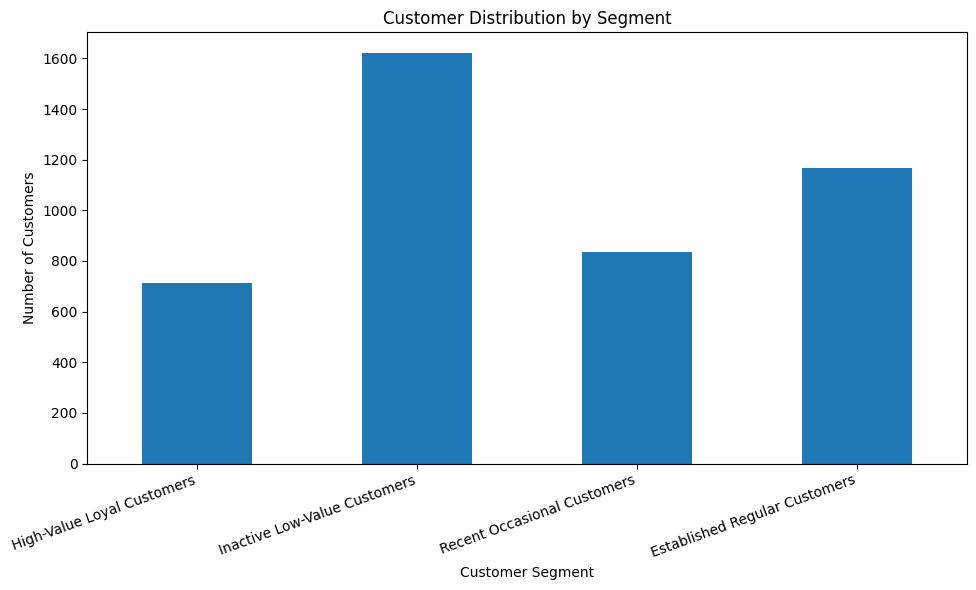

In [23]:
import matplotlib.pyplot as plt

# Count customers in each segment
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reindex([
        "High-Value Loyal Customers",
        "Inactive Low-Value Customers",
        "Recent Occasional Customers",
        "Established Regular Customers"
    ])
)

# Plot customer distribution
plt.figure(figsize=(10, 6))
segment_counts.plot(kind="bar")

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [24]:
# Attach the final cluster labels to the scaled customer features
profile_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

profile_scaled["Cluster"] = rfm["Cluster"].values
profile_scaled["Segment"] = rfm["Segment"].values

# Calculate the average standardised profile of each segment
segment_profile = (
    profile_scaled
    .groupby("Segment")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .reindex([
        "High-Value Loyal Customers",
        "Inactive Low-Value Customers",
        "Recent Occasional Customers",
        "Established Regular Customers"
    ])
)

segment_profile.round(2)

,Recency,Frequency,Monetary
Segment,,,
High-Value Loyal Customers,-1.24,1.66,1.41
Inactive Low-Value Customers,0.88,-0.78,-0.80
Recent Occasional Customers,-0.86,-0.35,-0.39
Established Regular Customers,0.15,0.32,0.53


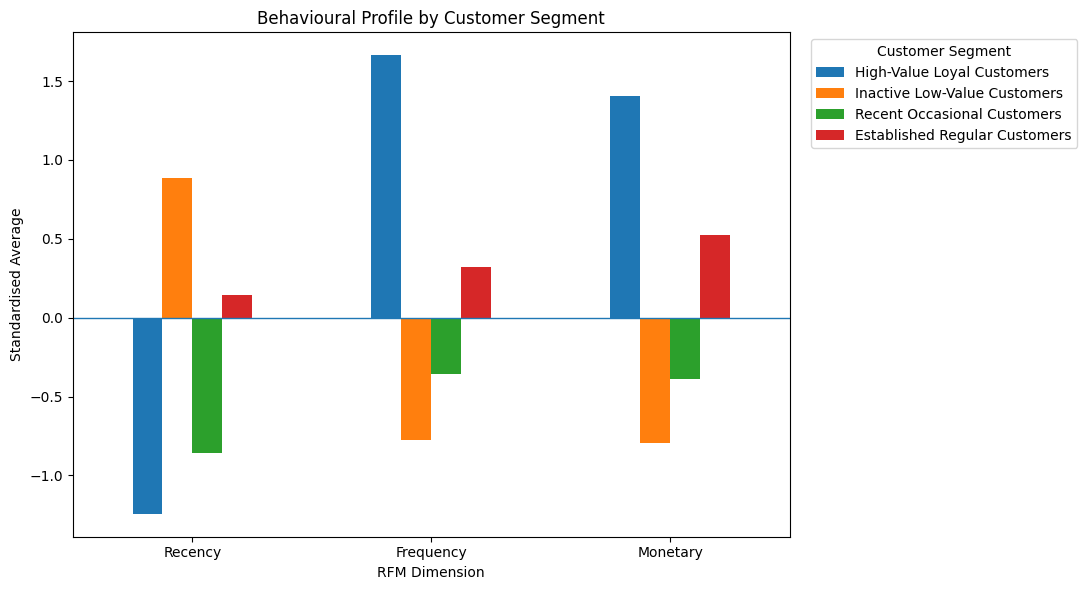

In [25]:
# Visualise the behavioural profile of each customer segment
segment_profile.T.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.axhline(0, linewidth=1)

plt.title("Behavioural Profile by Customer Segment")
plt.xlabel("RFM Dimension")
plt.ylabel("Standardised Average")
plt.xticks(rotation=0)
plt.legend(title="Customer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Business Insights and Recommended Actions

### High-Value Loyal Customers

These customers are the most recent, frequent and valuable purchasers in the dataset.

**Recommended actions:**
- Prioritise retention and loyalty initiatives.
- Offer early access to new products or premium services.
- Use personalised cross-selling and upselling strategies.
- Avoid excessive discounting that could reduce value unnecessarily.

### Inactive Low-Value Customers

These customers have not purchased recently, typically purchased only once and generated relatively low monetary value.

**Recommended actions:**
- Use low-cost reactivation campaigns rather than expensive retention initiatives.
- Test targeted incentives to encourage a return purchase.
- Monitor response before allocating additional marketing resources.

### Recent Occasional Customers

These customers have purchased recently but still show low purchase frequency and relatively limited monetary value.

**Recommended actions:**
- Encourage a second or subsequent purchase while engagement is still recent.
- Use personalised product recommendations and follow-up communication.
- Develop onboarding or nurture campaigns designed to increase purchase frequency.

### Established Regular Customers

These customers purchase more consistently and generate meaningful value, although they are less active and valuable than the highest-value segment.

**Recommended actions:**
- Strengthen loyalty through relevant cross-selling opportunities.
- Encourage increased purchase frequency and basket value.
- Identify customers with potential to migrate into the high-value loyal segment.

## Interpretation

The segmentation reveals different stages of customer engagement rather than a simple division between high-value and low-value customers.

This makes the four-cluster solution more actionable for customer strategy, as each segment can be approached with different retention, reactivation and growth initiatives.

In [26]:
# Quantify the business contribution of each customer segment
business_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Monetary=("Monetary", "sum"),
        Median_Recency=("Recency", "median"),
        Median_Frequency=("Frequency", "median"),
        Median_Monetary=("Monetary", "median")
    )
    .reset_index()
)

business_summary["Customer_Share_%"] = (
    business_summary["Customers"] / business_summary["Customers"].sum() * 100
)

business_summary["Monetary_Share_%"] = (
    business_summary["Total_Monetary"] / business_summary["Total_Monetary"].sum() * 100
)

business_summary[
    [
        "Segment",
        "Customers",
        "Customer_Share_%",
        "Monetary_Share_%",
        "Median_Recency",
        "Median_Frequency",
        "Median_Monetary"
    ]
].round(2)

,Segment,Customers,Customer_Share_%,Monetary_Share_%,Median_Recency,Median_Frequency,Median_Monetary
0,Established Regular Customers,1166,26.88,23.64,57.0,4.0,1345.20
1,High-Value Loyal Customers,713,16.44,64.89,8.0,10.0,3722.82
2,Inactive Low-Value Customers,1622,37.39,6.22,174.5,1.0,296.09
3,Recent Occasional Customers,837,19.29,5.25,17.0,2.0,480.31


## Key Findings

The analysis identified four customer segments with clearly different purchasing behaviours and economic contributions.

- **High-Value Loyal Customers** represent only 16.44% of customers but generate 64.89% of total monetary value. Their recent activity, high purchase frequency and strong spending make them the most strategically important segment for retention.

- **Established Regular Customers** account for 26.88% of customers and contribute 23.64% of total monetary value. They form a substantial base of repeat customers with potential to increase both purchase frequency and value.

- **Inactive Low-Value Customers** are the largest segment at 37.39% of the customer base but contribute only 6.22% of total monetary value. This suggests that reactivation efforts should be carefully targeted and cost-efficient.

- **Recent Occasional Customers** represent 19.29% of customers and contribute 5.25% of monetary value. Their recent engagement creates an opportunity to encourage repeat purchases and develop longer-term customer relationships.

## Conclusion

Customer value is highly concentrated within a relatively small proportion of the customer base.

The four-cluster solution provides a more actionable view of customer behaviour than a simple high-value versus low-value distinction. It enables differentiated strategies for retention, customer development and reactivation.

The project also demonstrates how transactional retail data can be transformed into customer-level behavioural features and used with unsupervised machine learning to support business decision-making.

## Limitations and Next Steps

This analysis uses Recency, Frequency and Monetary value as the primary behavioural dimensions. Future development could include additional features such as average order value, product diversity, purchasing cadence, country or return behaviour.

Alternative clustering techniques could also be compared with K-Means to evaluate the stability and robustness of the identified customer segments.

In [27]:
# Final technical validation

print(
    "Missing values in RFM features:",
    rfm[["Recency", "Frequency", "Monetary"]].isna().sum().sum()
)

print(
    "Duplicate customers:",
    rfm["CustomerID"].duplicated().sum()
)

print(
    "Finite scaled values:",
    np.isfinite(rfm_scaled).all()
)

print(
    "Number of clusters:",
    rfm["Cluster"].nunique()
)

print(
    "Final silhouette score:",
    round(silhouette_score(rfm_scaled, rfm["Cluster"]), 3)
)

Missing values in RFM features: 0
Duplicate customers: 0
Finite scaled values: True
Number of clusters: 4
Final silhouette score: 0.338
